# Midterm Examine / Categorical Data Analysis

2026/04/30

711478903-徐健華

In [1]:
suppressMessages(install.packages('vcd', quiet = TRUE))
suppressMessages(install.packages("pROC", quiet = TRUE))
suppressMessages(install.packages("VGAM", quiet = TRUE))

## Q1: 台灣手機佔有率問題。

某調查針對台灣及香港估計手機品牌市占率，資料顯示如下：

In [2]:
cc <- matrix(c(110, 36, 12, 8, 44, 50, 17, 10, 0, 23), 5, 2); cc <- t(cc)
colnames(cc) <- c("Apple", "Samsung", "OPPO", "Xiaomi", "Others")
rownames(cc) <- c("Taiwan", "Hong Kong")
cc

,Apple,Samsung,OPPO,Xiaomi,Others
Taiwan,110,36,12,8,44
Hong Kong,50,17,10,0,23


- (20%) 請利用統計檢定來審視 $H_0: Apple 手機佔有率在台灣為 50\%$ vs $H_a: Apple 手機佔有率在台灣不為 50\%$。
- (20%) 請利用Odds Ratio的概念來檢視是否台灣人比香港人更愛用Apple手機。
- (20%) 請檢定是否佔有率與臺港二地是否獨立。

(20%) 請利用統計檢定來審視 $H_0: Apple 手機佔有率在台灣為 50\%$ vs $H_a: Apple 手機佔有率在台灣不為 50\%$。

$ H_0: \pi = 0.5 $ vs. $ H_a: \pi \neq 0.5 $

分別使用Wald test與 Score test：

區間估計：

Wald:

$
\hat{\pi} \pm z_{\alpha/2}\sqrt{\frac{\hat{\pi}(1-\hat{\pi})}{n}}
$

Sroce:

$
\hat{\pi}\left(\frac{n}{n+z_{\alpha/2}^2}\right)+
\frac{1}{2}\left(\frac{z_{\alpha/2}^2}{n+z_{\alpha/2}^2}\right)
\pm\sqrt{\frac{1}{n+z_{\alpha/2}^2}\left[\left(\frac{n\hat{\pi}(1-\hat{\pi})}{n+z_{\alpha/2}^2}\right)+
                                            \left(\frac{z_{\alpha/2}^2}{4(n+z_{\alpha/2}^2)}\right)\right]}
$


In [3]:
tw_total <- sum(cc[1,])
tw_apple <- cc[1, "Apple"]
pi_hat <- tw_apple / tw_total
n <- tw_total
alpha <- 0.05

# Wald CI
se <- sqrt(pi_hat * (1 - pi_hat) / n)
z <- qnorm(1 - alpha / 2)
wald_ub <- pi_hat + z * se
wald_lb <- pi_hat - z * se
cat("Wald 95% CI is [", wald_lb, ", ", wald_ub, "]\n")

# Score CI
mu <- pi_hat * (n/(n + z^2)) + 0.5 * (z^2/(n + z^2))
sigma <- sqrt((1/(n+z^2)) * ((n * pi_hat * (1-pi_hat)/(n+z^2)) + (z^2/(4*(n+z^2)))))
score_ub <- mu + z * sigma
score_lb <- mu - z * sigma
cat("Score 95% CI is [", score_lb, ", ", score_ub, "]\n")

Wald 95% CI is [ 0.4562611 ,  0.591358 ]
Score 95% CI is [ 0.4564414 ,  0.5903222 ]


結論：

在95%信心水準下，Wald test與Score test信賴區間皆包含0.5，故不拒絕虛無假設，沒有足夠證據顯示Apple 手機佔有率在台灣不為50%。


(20%) 請利用Odds Ratio的概念來檢視是否台灣人比香港人更愛用Apple手機。

$ H_0: \theta = 1 $

估計量 Odds Ratio:

$$
\theta = \frac{\pi_{11} \pi_{22}}{\pi_{12}\pi_{21}}
$$

$$
\widehat{Var}(\log(\hat{\theta})) = \frac{1}{n_{11}} + \frac{1}{n_{12}} + \frac{1}{n_{21}} + \frac{1}{n_{22}}
$$

> 若任一格為0, 則須每格+0.5


區間估計：$ (1-\alpha)\times 100\% $ CI of $\theta $ is

$$
\log(\hat{\theta}) \pm z_{\alpha/2} \times \sqrt{\widehat{Var}\left(\log(\hat{\theta})\right)}
$$

In [4]:
# 將 cc 重建為 Apple 和 Non-Apple / Taiwan 和 Hong Kong 的 2x2 表格
cc_2x2 <- matrix(c(cc[1, "Apple"], sum(cc[1,]) - cc[1, "Apple"],
                   cc[2, "Apple"], sum(cc[2,]) - cc[2, "Apple"])
                   , 2, 2)
cc_2x2 <- t(cc_2x2)               
colnames(cc_2x2) <- c("Apple", "Non-Apple")
rownames(cc_2x2) <- c("Taiwan", "Hong Kong")
# cc_2x2

theta_hat <- (cc_2x2[1,1]*cc_2x2[2,2]) / (cc_2x2[1,2]*cc_2x2[2,1]); print(theta_hat)
log_theta_hat <- log(theta_hat)
var_log_theta_hat <- (1/cc_2x2[1,1]) + (1/cc_2x2[1,2]) + (1/cc_2x2[2,1]) + (1/cc_2x2[2,2])
alpha <- 0.05
z <- qnorm(1 - alpha / 2)
ub <- exp(log_theta_hat + z * sqrt(var_log_theta_hat))
lb <- exp(log_theta_hat - z * sqrt(var_log_theta_hat))
cat("95% CI for odds ratio is [", lb, ", ", ub, "]\n")


[1] 1.1
95% CI for odds ratio is [ 0.683089 ,  1.771365 ]


結論：

- 台灣使用Apple與非使用Apple比例是香港(Apple與非使用Apple)的1.1倍。
- 在95%信心水準下，Odds Ratio信賴區間包含1，故不拒絕虛無假設，沒有足夠證據顯示台灣人比香港人更愛用Apple手機。

(20%) 請檢定是否佔有率與臺港二地是否獨立。

使用卡方檢定須每格期望值 $E_{ij} >= 5$
但Xiaomi手機期望值未達 5，將OPPO與Xiaomi(皆為中國手機品牌)合併為一行計算

In [5]:
# E_24 <- (sum(cc[2,]) * sum(cc[,4])) / sum(cc); print(E_24)

cc_comb <- matrix(c(cc[1, "Apple"], cc[1, "Samsung"], sum(cc[1, "OPPO"], cc[1, "Xiaomi"]), cc[1, "Others"],
                    cc[2, "Apple"], cc[2, "Samsung"], sum(cc[2, "OPPO"], cc[2, "Xiaomi"]), cc[2, "Others"]),
                  4, 2)
cc_comb <- t(cc_comb)
colnames(cc_comb) <- c("Apple", "Samsung", "OPPO+Xiaomi", "Others")
rownames(cc_comb) <- c("Taiwan", "Hong Kong")
cc_comb


,Apple,Samsung,OPPO+Xiaomi,Others
Taiwan,110,36,20,44
Hong Kong,50,17,10,23


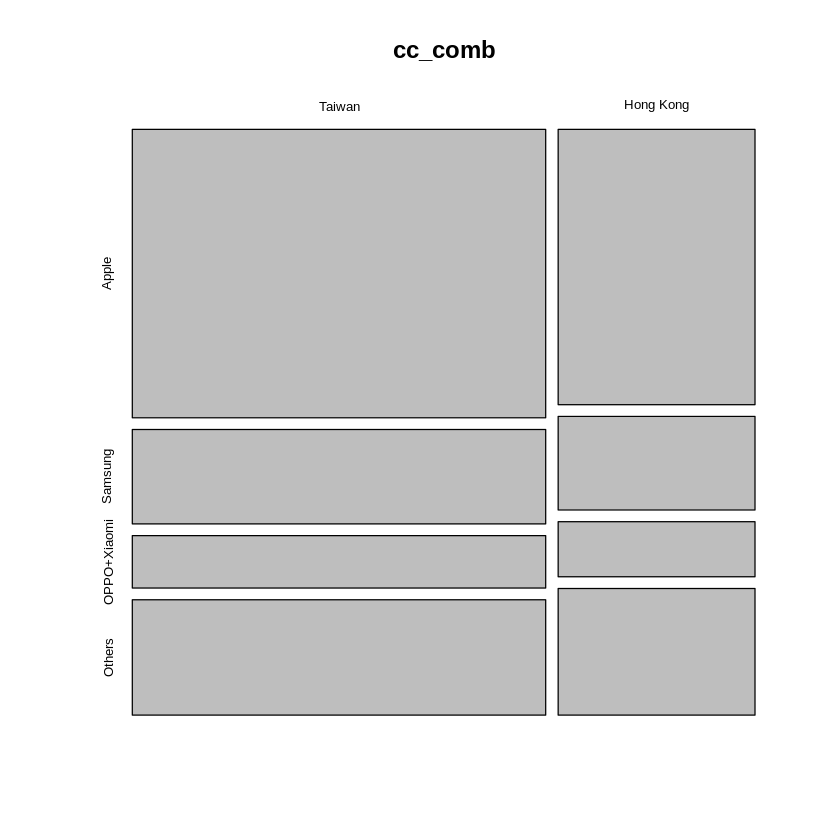

In [18]:
library(vcd)
mosaicplot(cc_comb)

In [7]:
ct <- chisq.test(cc_comb)
ct


	Pearson's Chi-squared test

data:  cc_comb
X-squared = 0.2225, df = 3, p-value = 0.9739


結論：

- 根據卡方檢定，臺港與手機佔有率無顯著相關 p-value > 0.05。


## Q2: 乳癌預測。

- (20%) 這個乳癌資料庫來自University of Wisconsin Hospitals（威斯康辛大學醫院，麥迪遜），由William H. Wolberg醫師提供。其內容為截至 1992 年 7 月 15 日止，對 699 位乳房腫瘤病患的切片檢查結果所進行的評估。九項腫瘤特徵皆以 1 至 10 分量表進行評分，並已知每位病患的最終診斷結果。此資料集共有 699 筆觀測值與 11 個欄位。請建構一預測模型，並執行模型選型，並評價其預測能力。

In [8]:
library(MASS)
data(biopsy)
str(biopsy)

'data.frame':	699 obs. of  11 variables:
 $ ID   : chr  "1000025" "1002945" "1015425" "1016277" ...
 $ V1   : int  5 5 3 6 4 8 1 2 2 4 ...
 $ V2   : int  1 4 1 8 1 10 1 1 1 2 ...
 $ V3   : int  1 4 1 8 1 10 1 2 1 1 ...
 $ V4   : int  1 5 1 1 3 8 1 1 1 1 ...
 $ V5   : int  2 7 2 3 2 7 2 2 2 2 ...
 $ V6   : int  1 10 2 4 1 10 10 1 1 1 ...
 $ V7   : int  3 3 3 3 3 9 3 3 1 2 ...
 $ V8   : int  1 2 1 7 1 7 1 1 1 1 ...
 $ V9   : int  1 1 1 1 1 1 1 1 5 1 ...
 $ class: Factor w/ 2 levels "benign","malignant": 1 1 1 1 1 2 1 1 1 1 ...


變數說明：

- 反應變數： class = benign(良性)； = malignant(惡性)。
- 自變數：
  - v1: 腫塊厚度
  - v2: 細胞數
  - v3: 細胞平整度
  - v4: 邊緣黏附程度
  - v5: 上表皮細胞數
  - v6: 裸核數
  - v7: 均勻染色質數
  - v8: 正常核仁數
  - v9: 有絲分裂數

In [9]:
## remove NA values
sel <- which(is.na(biopsy$V6))
bio2 <- biopsy[-sel,]
## remove id
bio2 <- bio2[,-1]

## first model
out <- glm(class~., data=bio2, family="binomial")
summary(out)


Call:
glm(formula = class ~ ., family = "binomial", data = bio2)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -10.10394    1.17488  -8.600  < 2e-16 ***
V1            0.53501    0.14202   3.767 0.000165 ***
V2           -0.00628    0.20908  -0.030 0.976039    
V3            0.32271    0.23060   1.399 0.161688    
V4            0.33064    0.12345   2.678 0.007400 ** 
V5            0.09663    0.15659   0.617 0.537159    
V6            0.38303    0.09384   4.082 4.47e-05 ***
V7            0.44719    0.17138   2.609 0.009073 ** 
V8            0.21303    0.11287   1.887 0.059115 .  
V9            0.53484    0.32877   1.627 0.103788    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 884.35  on 682  degrees of freedom
Residual deviance: 102.89  on 673  degrees of freedom
AIC: 122.89

Number of Fisher Scoring iterations: 8


In [10]:
## Backward selection by AIC
step.fit <- step(out, direction = "backward")

Start:  AIC=122.89
class ~ V1 + V2 + V3 + V4 + V5 + V6 + V7 + V8 + V9

       Df Deviance    AIC
- V2    1   102.89 120.89
- V5    1   103.27 121.27
- V3    1   104.74 122.74
<none>      102.89 122.89
- V9    1   106.61 124.61
- V8    1   106.66 124.66
- V4    1   110.31 128.31
- V7    1   110.33 128.33
- V1    1   120.72 138.72
- V6    1   122.07 140.07

Step:  AIC=120.89
class ~ V1 + V3 + V4 + V5 + V6 + V7 + V8 + V9

       Df Deviance    AIC
- V5    1   103.27 119.27
<none>      102.89 120.89
- V9    1   106.66 122.66
- V3    1   106.66 122.66
- V8    1   106.76 122.76
- V4    1   110.64 126.64
- V7    1   110.70 126.70
- V1    1   121.10 137.10
- V6    1   122.07 138.07

Step:  AIC=119.27
class ~ V1 + V3 + V4 + V6 + V7 + V8 + V9

       Df Deviance    AIC
<none>      103.27 119.27
- V9    1   107.14 121.14
- V8    1   107.72 121.72
- V3    1   107.90 121.90
- V7    1   111.69 125.69
- V4    1   112.17 126.17
- V1    1   121.55 135.55
- V6    1   123.15 137.15


In [11]:
summary(step.fit)


Call:
glm(formula = class ~ V1 + V3 + V4 + V6 + V7 + V8 + V9, family = "binomial", 
    data = bio2)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.98278    1.12610  -8.865  < 2e-16 ***
V1           0.53400    0.14079   3.793 0.000149 ***
V3           0.34529    0.17164   2.012 0.044255 *  
V4           0.34249    0.11922   2.873 0.004068 ** 
V6           0.38830    0.09356   4.150 3.32e-05 ***
V7           0.46194    0.16820   2.746 0.006025 ** 
V8           0.22606    0.11097   2.037 0.041644 *  
V9           0.53119    0.32446   1.637 0.101598    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 884.35  on 682  degrees of freedom
Residual deviance: 103.27  on 675  degrees of freedom
AIC: 119.27

Number of Fisher Scoring iterations: 8


模型選擇分析：

- Backward AIC 保留 V1 + V3 + V4 + V6 + V7 + V8 + V9 ，AIC為從122.89下降至119.27。
- V2(細胞數)被踢出，AIC下降至120.89，V5(上表皮細胞數)被踢出，AIC下降之119.27。
- V9(有絲分裂數)雖p-value不顯著，但移除V9會使AIC上升至121.14，故保留。


AUC: 0.9963436 


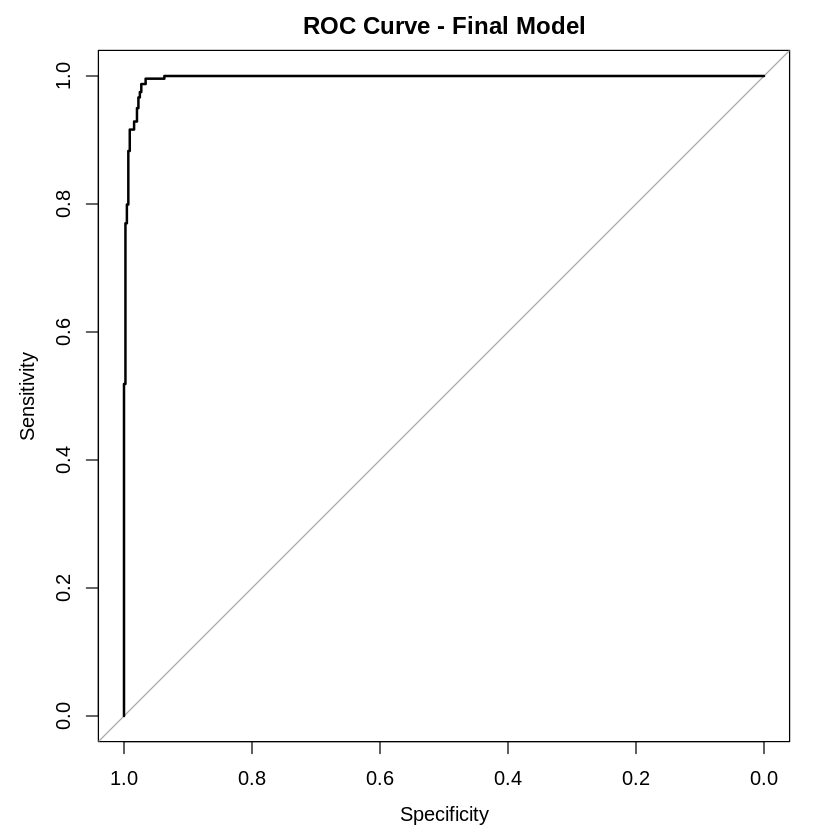

In [21]:
final.fit <- step.fit
suppressMessages(suppressWarnings(library(pROC)))
pred_prob <- predict(final.fit, type = "response")
roc_final <- roc(bio2$class, pred_prob, levels = c("benign", "malignant"), direction = "<")
cat("AUC:", auc(roc_final), "\n")
plot(roc_final, main = "ROC Curve - Final Model")

結論：

AUC = 0.9963，顯示模型具有良好的辨別力。

## Q3: 住宅滿意度調查

- (20%) 丹麥住宅滿意度調查結果如下：

In [13]:
library(MASS)
data(housing)
str(housing)

'data.frame':	72 obs. of  5 variables:
 $ Sat : Ord.factor w/ 3 levels "Low"<"Medium"<..: 1 2 3 1 2 3 1 2 3 1 ...
 $ Infl: Factor w/ 3 levels "Low","Medium",..: 1 1 1 2 2 2 3 3 3 1 ...
 $ Type: Factor w/ 4 levels "Tower","Apartment",..: 1 1 1 1 1 1 1 1 1 2 ...
 $ Cont: Factor w/ 2 levels "Low","High": 1 1 1 1 1 1 1 1 1 1 ...
 $ Freq: int  21 21 28 34 22 36 10 11 36 61 ...


請用四個自變數(Infl, Type, Cont, Freq) 預測滿意度(sat)。

- 反應變數： sat = Low, Medium, High (住宅滿意度)
- 自變數：
  - Infl: 住戶對於房產管理事務所感受到的影響力程度。
  - Type: 住宅型式 (Tower, Atrium, Apartment, Terrace)。
  - Cont: 住戶與其他住戶之間所獲得的互動機會 (Low, High)。
  - Freq: 住宅內人數。

In [16]:
suppressMessages(library(VGAM))
model <- vglm(Sat ~ Infl + Type + Cont + Freq,
              data = housing,
              family = cumulative(parallel=TRUE))
summary(model)


Call:
vglm(formula = Sat ~ Infl + Type + Cont + Freq, family = cumulative(parallel = TRUE), 
    data = housing)

Coefficients: 
              Estimate Std. Error z value Pr(>|z|)  
(Intercept):1 -0.14853    0.71048  -0.209    0.834  
(Intercept):2  1.26730    0.72628   1.745    0.081 .
InflMedium     0.05870    0.53435   0.110    0.913  
InflHigh      -0.26096    0.56415  -0.463    0.644  
TypeApartment  0.53295    0.72602   0.734    0.463  
TypeAtrium    -0.21626    0.63728  -0.339    0.734  
TypeTerrace   -0.18602    0.62974  -0.295    0.768  
ContHigh       0.19316    0.45492   0.425    0.671  
Freq          -0.02810    0.01914  -1.468    0.142  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Names of linear predictors: logitlink(P[Y<=1]), logitlink(P[Y<=2])

Residual deviance: 156.3338 on 135 degrees of freedom

Log-likelihood: -78.1669 on 135 degrees of freedom

Number of Fisher scoring iterations: 6 


Exponentiated coefficients:
   InflMedium      InflHigh

所有變數皆不顯著 p-value > 0.05，原資料可能是將滿意度累積計算，而freq變數則是累積數量，嘗試從將freq進行轉換，將原資料變為寬資料。

In [17]:
# 轉寬格式
low    <- housing[housing$Sat=="Low",    c("Infl","Type","Cont","Freq")]
medium <- housing[housing$Sat=="Medium", c("Infl","Type","Cont","Freq")]
high   <- housing[housing$Sat=="High",   c("Infl","Type","Cont","Freq")]

housing_wide <- merge(merge(low, medium, by=c("Infl","Type","Cont")),
                      high, by=c("Infl","Type","Cont"))
names(housing_wide)[4:6] <- c("Low","Medium","High")

# 重新建立模型
model_cbind <- vglm(cbind(Low, Medium, High) ~ Infl + Type + Cont,
                    data   = housing_wide,
                    family = cumulative(parallel=TRUE))
summary(model_cbind)


Call:
vglm(formula = cbind(Low, Medium, High) ~ Infl + Type + Cont, 
    family = cumulative(parallel = TRUE), data = housing_wide)

Coefficients: 
              Estimate Std. Error z value Pr(>|z|)    
(Intercept):1 -0.49614    0.12454  -3.984 6.78e-05 ***
(Intercept):2  0.69071    0.12521   5.516 3.46e-08 ***
InflMedium    -0.56639    0.10496  -5.396 6.81e-08 ***
InflHigh      -1.28882    0.12670 -10.172  < 2e-16 ***
TypeApartment  0.57235    0.11875   4.820 1.44e-06 ***
TypeAtrium     0.36619    0.15677   2.336 0.019498 *  
TypeTerrace    1.09101    0.15151   7.201 5.99e-13 ***
ContHigh      -0.36028    0.09536  -3.778 0.000158 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Names of linear predictors: logitlink(P[Y<=1]), logitlink(P[Y<=2])

Residual deviance: 47.7276 on 40 degrees of freedom

Log-likelihood: -123.432 on 40 degrees of freedom

Number of Fisher scoring iterations: 4 


Exponentiated coefficients:
   InflMedium      InflHigh TypeApartment    T

結論：

所有自變數均為顯著（p < 0.05），模型具有良好解釋力。影響住宅滿意度的因素依顯著程度排序：
1. Infl（住戶對於房產管理事務所感受到的影響力程度）效果最強，InflHigh 的 OR = 0.276，是影響最大的變數
2. Type（住宅型式）中 Terrace 滿意度顯著最低，Tower 最高
3. Cont（住戶與其他住戶之間所獲得的互動機會）高互動有助於提升滿意度